In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function

from critical_points.torch_critical_point_finder import find_critical_points_torch, save_critical_points_to_csv
from test_schwefel.schwefel_function_nnmodule import Schwefel2D, schwefel_loss, schwefel2D_numpy 

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
model_builder = lambda p: Schwefel2D(*p)

In [3]:
# Set parameters
BOUNDS = (0.0, 1.0)
DIM = 2
ATTEMPTS = 128
MIN_DISTANCE = 0.01


In [4]:
# Run search
minima, maxima, saddles = find_critical_points_torch(
    model_builder=model_builder,
    loss_func=schwefel_loss,
    input = [],             # placeholder model input for compatibility (Schwefel model has no model input)
    bounds=BOUNDS,
    dimension=DIM,
    num_attempts=ATTEMPTS,
    min_distance=MIN_DISTANCE,
    device="cpu",
    lr=5e-2,
    max_iter=5_000,
    seed=1101
)



__________________________________________________________________________________________
Attempt 1/128:
Starting point: [0.25317813 0.88321528]
learning rate 0.05
Converged after 256 iterations.
check grad tensor([-7.8352e-06,  5.6196e-06], grad_fn=<CatBackward0>)
[0.56116667 0.8243751 ] Reject: False
Type: saddle

__________________________________________________________________________________________
Attempt 2/128:
Starting point: [0.76250551 0.35659261]
learning rate 0.05
Converged after 246 iterations.
check grad tensor([-9.4134e-06,  2.5218e-06], grad_fn=<CatBackward0>)
[0.82437482 0.3418095 ] Reject: False
Type: minimum

__________________________________________________________________________________________
Attempt 3/128:
Starting point: [0.65636731 0.73049768]
learning rate 0.05
Converged after 258 iterations.
check grad tensor([-6.8369e-06, -6.7252e-06], grad_fn=<CatBackward0>)
[0.56116665 0.82437487] Reject: True

_______________________________________________________

In [5]:
# Save to CSV
results_df = save_critical_points_to_csv(minima, maxima, saddles, dimension=DIM, filename="critical_points_schwefel_torch.csv")
display(results_df)

Saved critical_points_schwefel_torch.csv


,x1,x2,f_value,type,index
0,0.824375,0.341809,-0.201843,minimum,0
1,0.824375,0.034551,-0.063635,minimum,0
2,0.034551,0.341809,0.153505,minimum,0
3,0.824375,0.824375,-0.418983,minimum,0
4,0.341810,0.824375,-0.201843,minimum,0
5,0.341809,0.341809,0.015296,minimum,0
6,0.034551,0.034551,0.291713,minimum,0
7,0.341809,0.034551,0.153505,minimum,0
8,0.034551,0.824375,-0.063635,minimum,0
9,0.561167,0.166288,0.842404,maximum,2


/tmp/ipykernel_223044/4189154570.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


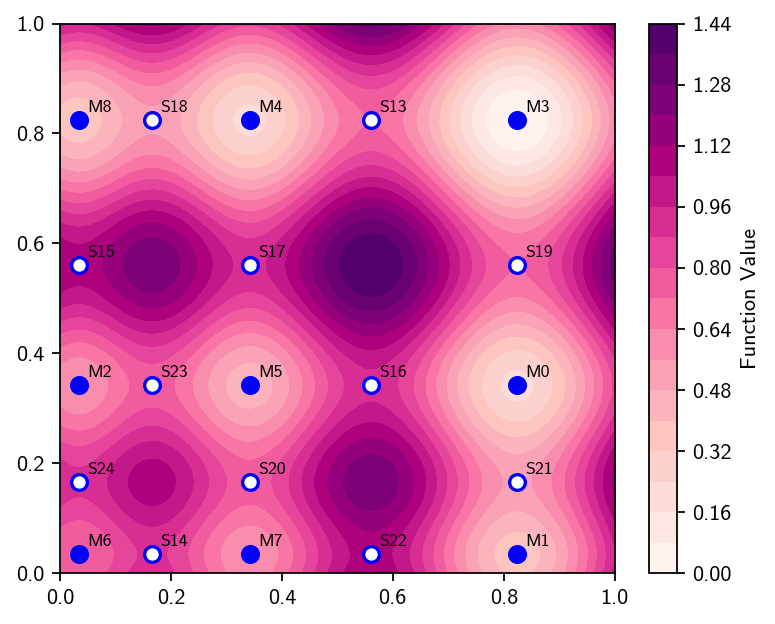

In [6]:
fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=results_df,
                                connectivity_df=None, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
plt.xlim(BOUNDS[0],BOUNDS[1])
plt.ylim(BOUNDS[0],BOUNDS[1])
fig2.show()
fig2.savefig("plots/landscape_paths.png")  # Optional